In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
  
df = pd.read_csv(r'C:\Users\SuNi\Downloads\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print(df.shape)
df.info()

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
feature = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[feature]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [9]:
score = df.groupby('cluster')['Spending Score (1-100)'].mean().sort_values()
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [10]:
label_mapping = {
    score.index[0] : "Low Spenders",
    score.index[1] : "Medium Spenders",
    score.index[2] : "High Spenders"
}

df['Spending'] = df['cluster'].map(label_mapping)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Spending
0,1,Male,19,15,39,0,Medium Spenders
1,2,Male,21,15,81,0,Medium Spenders
2,3,Female,20,16,6,0,Medium Spenders
3,4,Female,23,16,77,0,Medium Spenders
4,5,Female,31,17,40,0,Medium Spenders


In [11]:
segment_summary = df.groupby('Spending').agg(
    Customer_count = ('CustomerID', 'count'),
    Avg_Age = ('Age', 'mean'),
    Avg_Income_K = ('Annual Income (k$)', 'mean'),
    Avg_Spending_score = ('Spending Score (1-100)', 'mean')
)

print(segment_summary.reindex(['Low Spenders', 'Medium Spenders', 'High Spenders']))

                 Customer_count    Avg_Age  Avg_Income_K  Avg_Spending_score
Spending                                                                    
Low Spenders                 91  51.274725     61.802198           34.208791
Medium Spenders              68  25.838235     42.750000           53.647059
High Spenders                41  32.853659     87.341463           79.975610


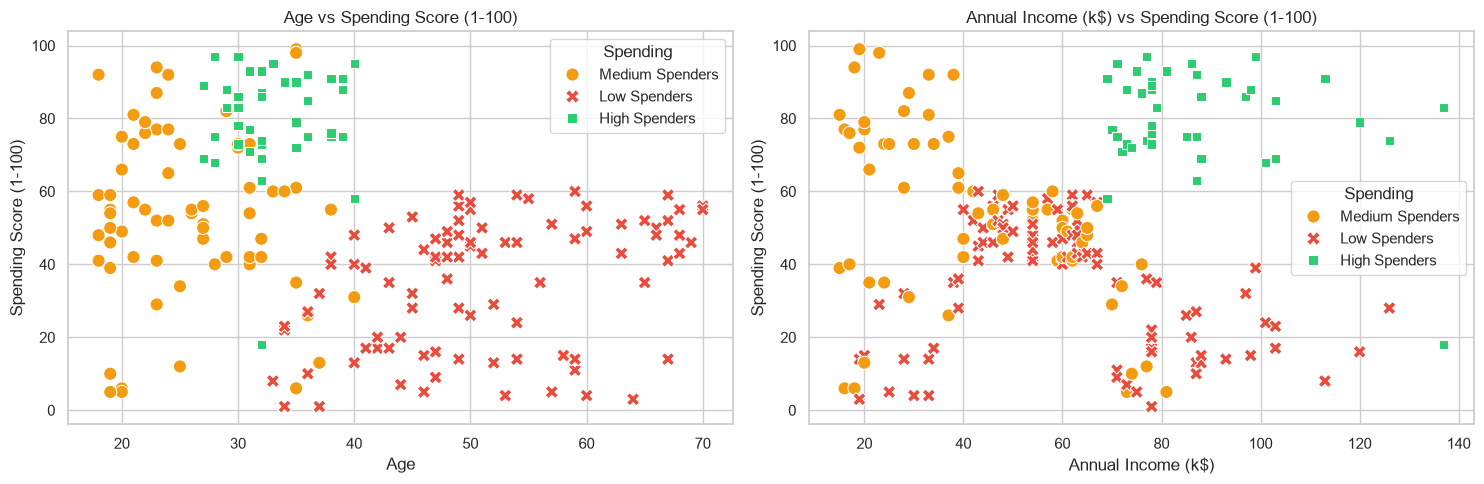

In [15]:
sns.set_theme(style = 'whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = {'Low Spenders': '#e74c3c', 'Medium Spenders': '#f39c12', 'High Spenders': '#2ecc71'}

sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Spending', palette=palette, style='Spending',
                s=90, ax=axes[0])
axes[0].set_title('Age vs Spending Score (1-100)')

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending', palette=palette, style='Spending',
                s=90, ax=axes[1])
axes[1].set_title('Annual Income (k$) vs Spending Score (1-100)')

plt.tight_layout()
plt.show()